In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from pathlib import Path

ROOT_PATH = "/bohr/MNIST-train-no-label-test-uwkr/v1"
class MyDataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y

    @staticmethod
    def _to_chw(image: torch.Tensor) -> torch.Tensor:
        if image.ndim == 1:
            if image.numel() == 28 * 28:
                return image.view(1, 28, 28)
            if image.numel() == 32 * 32:
                return image.view(1, 32, 32)
            if image.numel() == 3 * 32 * 32:
                return image.view(3, 32, 32)
            side = int(image.numel() ** 0.5)
            if side * side == image.numel():
                return image.view(1, side, side)
            raise ValueError(f"Unsupported flat image length: {image.numel()}")

        if image.ndim == 2:
            return image.unsqueeze(0)

        if image.ndim == 3 and image.shape[0] not in (1, 3) and image.shape[-1] in (1, 3):
            return image.permute(2, 0, 1)

        return image

    @staticmethod
    def _preprocess(image: torch.Tensor) -> torch.Tensor:
        # 支持单张图像 [C, H, W] 和批量图像 [B, C, H, W]
        if image.ndim == 4:
            return torch.stack([MyDataset._preprocess(item) for item in image], dim=0)

        image = MyDataset._to_chw(image)

        # 像素值统一到 [0, 1]
        if image.max() > 1.0:
            image = image / 255.0

        # 按通道标准化：1通道走MNIST统计量，3通道走CIFAR10统计量
        if image.shape[0] == 1:
            mean = torch.tensor([0.1307], dtype=image.dtype, device=image.device).view(-1, 1, 1)
            std = torch.tensor([0.3081], dtype=image.dtype, device=image.device).view(-1, 1, 1)
        else:
            mean = torch.tensor([0.4914, 0.4822, 0.4465], dtype=image.dtype, device=image.device).view(-1, 1, 1)
            std = torch.tensor([0.2470, 0.2435, 0.2616], dtype=image.dtype, device=image.device).view(-1, 1, 1)

        image = (image - mean) / (std + 1e-8)
        return image

    def __getitem__(self, idx):
        image = torch.tensor(self._x[idx], dtype=torch.float32)
        label = torch.tensor(self._y[idx], dtype=torch.long)

        # 先统一成 [C, H, W]
        image = self._to_chw(image)

        image = self._preprocess(image)
        return image, label

    def __len__(self):
        return len(self._x)

def prepare_data_loader(
    path: str,
    ratio: float = None,
    train_batch_size: int = 1,
    is_train: bool = True,
) -> dict:
    """
    参数:
        path (str): .npz格式的数据集文件路径
        ratio (float): 训练集比例
        train_batch_size (int): 批次大小
        num_workers (int): 数据加载的工作进程数
    返回:
        dict: 包含训练和测试数据加载器的字典
    """
    print("开始加载数据...")  # 添加调试信息
    train_dataset = torch.load(path)
    train_dataset = MyDataset(train_dataset[0], train_dataset[1])
    if is_train:
        train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [int(len(train_dataset) * ratio), len(train_dataset) - int(len(train_dataset) * ratio)])
        train_loader = torch.utils.data.DataLoader(
                                                    dataset=train_dataset, 
                                                batch_size=train_batch_size, 
                                                shuffle=True,
                                                drop_last=True,
                                                pin_memory=True  
                                                )
        val_loader = torch.utils.data.DataLoader(
                                                dataset=val_dataset, 
                                                batch_size=train_batch_size, 
                                                shuffle=False,
                                                pin_memory=True  
        )
        print("数据加载器创建完成")  # 添加调试信息

        return {"train": train_loader, "val": val_loader}
    else:
        test_loader = torch.utils.data.DataLoader(
                                                dataset=train_dataset, 
                                                batch_size=train_batch_size, 
                                                shuffle=False,
                                                pin_memory=True  
        )
        print("测试数据加载器创建完成")  # 添加调试信息

        return {"test": test_loader}


In [2]:
class SimpleMLP(nn.Module):
    """
    可配置的多层感知机模型
    
    参数:
        input_size (int): 输入特征维度 (对于CIFAR10是3*32*32=3072)
        num_classes (int): 分类类别数
        hidden_layers (list): 每个隐藏层的输出维度列表
        dropout_rate (float): Dropout比率
        activation (str): 激活函数类型 ('relu', 'tanh', 'sigmoid')
    """
    def __init__(
        self,
        input_size: int = 3072,  # 3*32*32 for CIFAR10
        num_classes: int = 10,
        hidden_layers: list = [512, 256, 128],  # 默认三层隐藏层
        dropout_rate: float = 0.1,
        activation: str = 'relu'
    ):
        super(SimpleMLP, self).__init__()
        
        # 选择激活函数
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")
            
        # 构建隐藏层
        self.fc_blocks = nn.ModuleList()
        current_dim = input_size
        
        for hidden_dim in hidden_layers:
            fc_block = nn.Sequential(
                nn.Linear(current_dim, hidden_dim),
                self.activation,
                nn.BatchNorm1d(hidden_dim),  # 添加批归一化
                nn.Dropout(dropout_rate)
            )
            self.fc_blocks.append(fc_block)
            current_dim = hidden_dim
            
        # 输出层
        self.output_layer = nn.Linear(current_dim, num_classes)

    def forward(self, x):
        # 展平输入
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        
        # 通过所有隐藏层
        for fc_block in self.fc_blocks:
            x = fc_block(x)
            
        # 输出层
        x = self.output_layer(x)
        return x
        

In [3]:
import torch.optim as optim
import time
import matplotlib.pyplot as plt

loss_fn = nn.CrossEntropyLoss()

def train_step(
    model: nn.Module, optimizer, batch: dict, device: torch.device
):
    batch_images, labels = batch
    batch_images = batch_images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    logits = model(batch_images)
    loss = loss_fn(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item(), logits, labels

def eval_step(model: nn.Module, batch: dict, device: torch.device):
    model.eval()
    with torch.no_grad():
        batch_images, labels = batch
        batch_images = batch_images.to(device)
        labels = labels.to(device)
        logits = model(batch_images)
        loss = loss_fn(logits, labels)
        return loss.item(), logits, labels

def validate(model, val_loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    num_batches = len(val_loader)
    num_data = len(val_loader.dataset)
    with torch.no_grad():
        for batch in val_loader:
            loss, logits, labels = eval_step(model, batch, device)
            total_loss += loss
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / num_batches
    accuracy = correct / num_data
    return avg_loss, accuracy * 100

def draw_curves(train_loss_steps, train_acc_steps, val_loss_steps, val_acc_steps,
                train_batch_indices, val_batch_indices):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(train_batch_indices, train_loss_steps, label='Train Loss', alpha=0.7)
    ax1.plot(val_batch_indices, val_loss_steps, 'o-', label='Val Loss', markersize=4)
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Batch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(train_batch_indices, train_acc_steps, label='Train Acc', alpha=0.7)
    ax2.plot(val_batch_indices, val_acc_steps, 'o-', label='Val Acc', markersize=4)
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Batch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

def controller(
    train_loader,
    val_loader,
    seed: int,
    input_size: int = None,
    hidden_layers: list = [512, 256, 128],
    activation: str = 'relu',
    num_classes: int = 10,
    dropout_rate: float = 0.1,
    ratio: float = 0.8,
    train_batch_size: int = 64,
    num_workers: int = 4,
    epochs: int = 10,
    learning_rate: float = 0.001,
    weight_decay: float = 0.004
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)

    model = SimpleMLP(
        input_size=input_size,
        num_classes=num_classes,
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
        activation=activation
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Recording lists
    train_loss_steps = []
    train_acc_steps = []
    val_loss_steps = []
    val_acc_steps = []
    train_batch_indices = []
    val_batch_indices = []

    best_acc = 0.0
    global_batch = 0
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for batch_idx, batch in enumerate(train_loader):
            loss, logits, labels = train_step(model, optimizer, batch, device)
            bs = labels.size(0)
            running_loss += loss * bs
            _, predicted = torch.max(logits, 1)
            running_correct += (predicted == labels).sum().item()
            running_total += bs
            global_batch += 1

            # Every 5 batches: print training info
            if global_batch % 5 == 0:
                elapsed = time.time() - start_time
                train_avg_loss = running_loss / running_total
                train_avg_acc = running_correct / running_total * 100
                print(f"Epoch {epoch+1} | Batch {global_batch} | "
                      f"Time: {elapsed:.1f}s | "
                      f"Train Loss: {train_avg_loss:.4f} | Train Acc: {train_avg_acc:.1f}%",
                      end="")

                # Every 10 batches: also run validation and print val info
                if global_batch % 10 == 0:
                    val_loss, val_acc = validate(model, val_loader, device)
                    model.train()  # switch back to train mode
                    print(f" | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}%")

                    # Record for plotting
                    train_loss_steps.append(train_avg_loss)
                    train_acc_steps.append(train_avg_acc)
                    val_loss_steps.append(val_loss)
                    val_acc_steps.append(val_acc)
                    train_batch_indices.append(global_batch)
                    val_batch_indices.append(global_batch)

                    if val_acc > best_acc:
                        best_acc = val_acc
                        torch.save(model.state_dict(), 'best_model.pth')

                    # Reset running stats after validation
                    running_loss = 0.0
                    running_correct = 0
                    running_total = 0
                else:
                    print()

        scheduler.step()

        # End of epoch: draw curves
        # # Run one final validation if not just done
        # if global_batch % 200 != 0:
        #     val_loss, val_acc = validate(model, val_loader, device)
        #     model.train()
        #     train_avg_loss = running_loss / running_total if running_total > 0 else 0
        #     train_avg_acc = running_correct / running_total * 100 if running_total > 0 else 0
        #     train_loss_steps.append(train_avg_loss)
        #     train_acc_steps.append(train_avg_acc)
        #     val_loss_steps.append(val_loss)
        #     val_acc_steps.append(val_acc)
        #     train_batch_indices.append(global_batch)
        #     val_batch_indices.append(global_batch)
        #     if val_acc > best_acc:
        #         best_acc = val_acc
        #         torch.save(model.state_dict(), 'best_model.pth')

        print(f"\n=== Epoch {epoch+1} finished ===")
        draw_curves(train_loss_steps, train_acc_steps, val_loss_steps, val_acc_steps,
                     train_batch_indices, val_batch_indices)

    print(f"\nTraining completed! Best accuracy: {best_acc:.2f}%")
    return model

def show_sample_images(sample, title):
    images, labels = sample
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    plt.figure(figsize=(8, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        if images.shape[1] == 1:
            plt.imshow(images[i][0], cmap='gray')
        else:
            img = np.transpose(images[i], (1, 2, 0))
            img = (img * np.array([0.2470, 0.2435, 0.2616]) + np.array([0.4914, 0.4822, 0.4465])) * 255.0
            img = np.clip(img.astype(np.uint8), 0, 255)
            plt.imshow(img)
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

开始加载数据...
数据加载器创建完成
/opt/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/opt/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


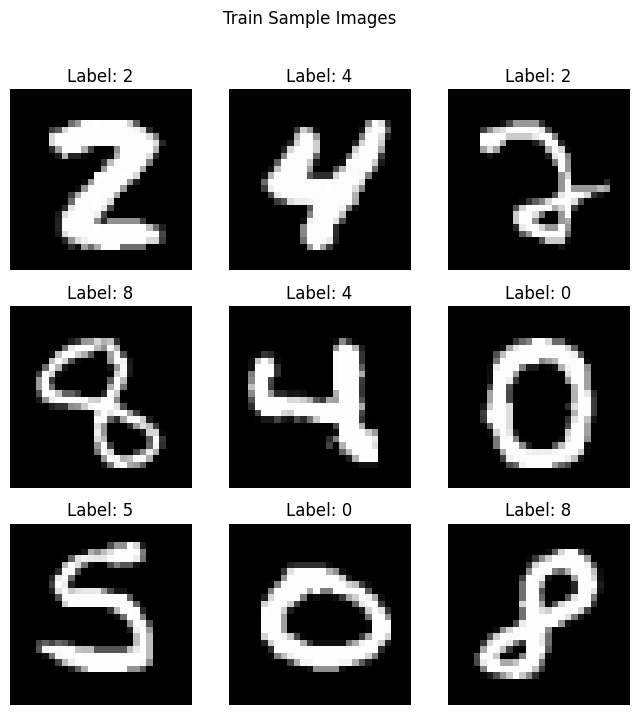

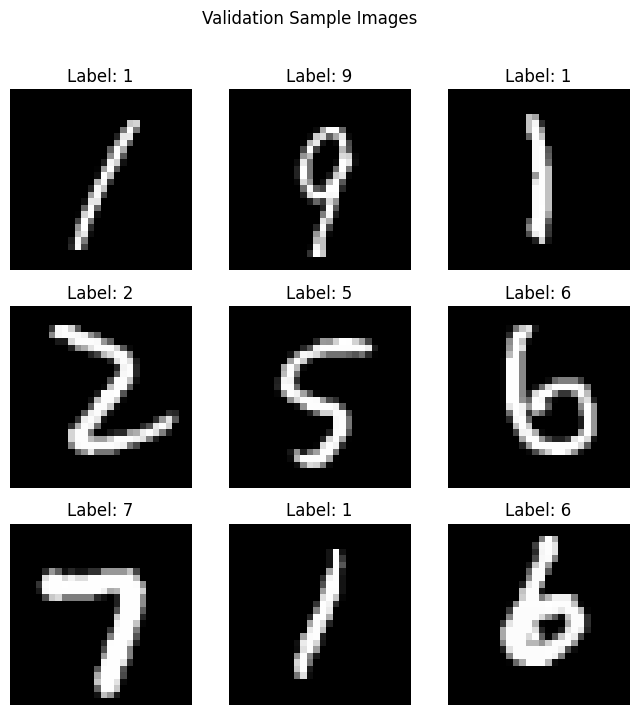

Epoch 1 | Batch 5 | Time: 0.6s | Train Loss: 1.4537 | Train Acc: 56.2%


In [4]:
# 随机数种子：确保每次运行代码得到相同的结果
# 请同学把随机种子改成自己的学号，方便助教后期验证结果的真实性。
seed = 525031910002
# 例如：
# seed = 12345678
# MNIST的输入特征维度是28*28=784，CIFAR10的输入特征维度是3*32*32=3072
input_size = 784
# hidden_layers 是一个列表，定义了每个隐藏层的输出维度。例如，hidden_layers=[512, 256, 128] 表示有三个隐藏层，分别有512、256和128个神经元。
hidden_layers = [128, 128, 128]
# activation 是一个字符串，指定了隐藏层使用的激活函数类型。常见的激活函数包括 'relu'（修正线性单元）、'tanh'（双曲正切）和 'sigmoid'（S形函数）。例如，activation='relu' 表示使用ReLU激活函数。
activation = 'relu'
# num_classes 是一个整数，表示分类任务中的类别数量。例如，对于CIFAR10数据集，num_classes=10，因为CIFAR10包含10个不同的类别。
num_classes = 10
# dropout_rate 是一个浮点数，表示在训练过程中应用的Dropout正则化的比率。Dropout是一种防止过拟合的技术，通过在训练过程中随机丢弃神经元来实现。例如，dropout_rate=0.1 表示每个神经元有10%的概率被丢弃。
dropout_rate = 0.1
# train_batch_size 是一个整数，表示在训练过程中每个批次中包含的样本数量。较大的批次大小可以加速训练，但可能需要更多的内存。例如，train_batch_size=64 表示每个批次包含64个样本。
train_batch_size: int = 1024
# epochs 是一个整数，表示整个训练数据集要被训练的次数。每个epoch表示模型已经看过整个训练数据集一次。例如，epochs=10 表示模型将对整个训练数据集进行10次迭代。
epochs: int = 10
# learning_rate 是一个浮点数，表示模型在训练过程中调整参数的步长。较大的学习率可能导致训练不稳定，而较小的学习率可能导致训练过慢。例如，
learning_rate: float = 0.002
# weight_decay 是一个浮点数，表示L2正则化的强度。L2正则化通过在损失函数中添加模型参数的平方和来防止过拟合。例如，
weight_decay: float = 0.004

#ratio比率：训练集中用于训练的数据量/总数据量
#比率0.8表示50000张图片中有40000张用于训练，10000用于测试
ratio = 0.85

loader_dict = prepare_data_loader(path=Path(f"{ROOT_PATH}/training.pt"), ratio=ratio, train_batch_size=train_batch_size,)
train_loader = loader_dict["train"]
val_loader = loader_dict["val"]
# 增加一个 train 和 val 的图像示意图
train_sample = next(iter(train_loader))
val_sample = next(iter(val_loader))

show_sample_images(train_sample, "Train Sample Images")
show_sample_images(val_sample, "Validation Sample Images")

model = controller(
    train_loader=train_loader,
    val_loader=val_loader,
    seed=seed,
    input_size=input_size,
    hidden_layers=hidden_layers,
    activation=activation,
    num_classes=num_classes,
    dropout_rate=dropout_rate,
        ratio = ratio,
        train_batch_size=train_batch_size,
        epochs=epochs,  
        learning_rate=learning_rate,
        weight_decay = weight_decay
)


In [ ]:
import os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluater_with_dataloader_and_save(model, test_path, device, solution_path=None):
    """
    使用 val_dataloader 计算准确率并可选择保存预测结果
    
    参数:
    - model: 需要评估的模型
    - val_loader: 测试数据加载器
    - device: 计算设备 (CPU 或 GPU)
    - solution_path: 保存预测结果的路径(可选)
    
    返回:
    - accuracy: 模型在测试集上的准确率
    """
    model.eval()  # 设置为评估模式
    all_predictions = []
    test_dataset = torch.load(test_path)
    
    test_dataset = MyDataset(test_dataset, torch.ones(len(test_dataset), dtype=torch.long))  # 创建一个假的标签数组，实际不会使用
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)
    all_ids = []
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(test_dataloader):
            images = images.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1).cpu().numpy()
            all_predictions.extend(predictions)
            all_ids.extend(range(batch_idx * 128, batch_idx * 128 + len(predictions)))
    
    # 保存预测结果
    if solution_path is not None:
        predictions_df = pd.DataFrame({"ID": all_ids, "label": all_predictions})
        predictions_df.to_csv(solution_path, index=False)
        print(f'预测结果已保存至 {solution_path}')

# test_dataloader = prepare_data_loader(path=Path(f"{ROOT_PATH}/test-shuffled-nolabel.pt"),train_batch_size=128, is_train=False)['test']
os.makedirs('/personal/MNIST/', exist_ok=True)
evaluater_with_dataloader_and_save(
    model,
    test_path=Path(f"{ROOT_PATH}/test-shuffled-nolabel.pt"),
    solution_path=Path("/personal/MNIST/525031910002-3.csv"),
    device = device
    )
